In [1]:
# 依赖库安装
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
import scipy.io
import tensorflow as tf
from PIL import Image
import numpy as np
# import torch
# import torch.nn as nn
import matplotlib.pyplot as plt
# import torch


2026-03-05 14:00:07.854659: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
#材料参数（论文 Table 1，w/c=0.4 那行，论文公式(6)(7)(8)
def solution(x1,x2):
    y_f = 12.1
    A_0 = 43.6
    
    A_1 =131.2
    
    C = 56.1
    a=2100
    b=9.45
    
    #（最核心）：把公式(6)(7)(8)合三为一
    y = y_f+(A_0+(A_1-A_0)*np.exp(-x2*x1/(a+b*x2)))*(np.arcsinh(x2/C))
    
    return y


Compiling model...
'compile' took 0.006038 s



Training model...



/home/raymondxu/miniconda3/envs/network/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Step      Train loss    Test loss     Test metric   
0         [9.74e+03]    [9.74e+03]    [1.01e+00]    
1000      [3.18e+03]    [3.18e+03]    [5.75e-01]    
2000      [1.57e+03]    [1.57e+03]    [4.03e-01]    
3000      [9.47e+02]    [9.47e+02]    [3.13e-01]    
4000      [5.65e+02]    [5.65e+02]    [2.42e-01]    
5000      [3.18e+02]    [3.18e+02]    [1.82e-01]    
6000      [1.65e+02]    [1.65e+02]    [1.31e-01]    
7000      [8.06e+01]    [8.06e+01]    [9.14e-02]    
8000      [3.54e+01]    [3.54e+01]    [6.06e-02]    
9000      [1.39e+01]    [1.39e+01]    [3.80e-02]    
10000     [5.05e+00]    [5.05e+00]    [2.29e-02]    
11000     [1.61e+00]    [1.61e+00]    [1.29e-02]    
12000     [5.02e-01]    [5.02e-01]    [7.22e-03]    
13000     [1.46e-01]    [1.46e-01]    [3.89e-03]    
14000     [6.99e-02]    [6.99e-02]    [2.69e-03]    
15000     [1.36e-01]    [1.36e-01]    [3.76e-03]    
16000     [1.05e-01]    [1.05e-01]    [3.30e-03]    
17000     [1.63e-02]    [1.63e-02]    [1.30e-0

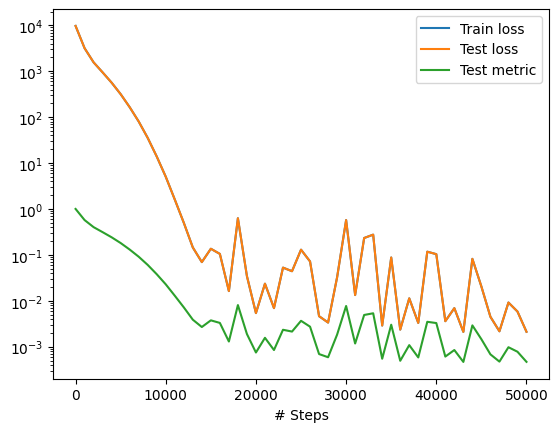

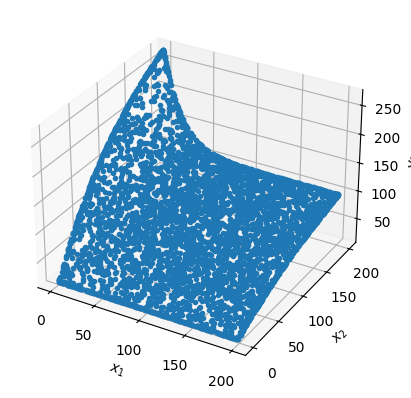

In [3]:
def PDE(x,y):
    
    x1,x2=x[:,0:1],x[:,1:2]#, t,shear rate

    y_f = 12.1
    A_0 = 43.6
    
    A_1 =131.2
    
    C = 56.1
    a=2100
    b=9.45
   
    eq1 = y_f+(A_0+(A_1-A_0)*tf.exp(-x2*x1/(a+b*x2)))*(tf.math.asinh(x2/C))-y
  
    return eq1

def func(x):
    
    return solution(x[:,0:1],x[:,1:2])

geom = dde.geometry.Rectangle([0, 0], [200, 200])

#geom = dde.geometry.TimeDomain(0, 200)
data = dde.data.PDE(geom, PDE, [], 3500, 1000,train_distribution='pseudo',solution=func, num_test=None)

layer_size = [2] + [50] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.maps.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(epochs=50000)

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# FNN training

In [6]:
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

train=np.loadtxt('train.dat', unpack = True)

x_train = train[[0,1]].T
y_train = train[2]

clf = MLPRegressor(hidden_layer_sizes=(50,50,50),max_iter=50000)

clf.fit(x_train, y_train)


,loss,'squared_error'
,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,50000
,shuffle,True


In [7]:
train1=np.loadtxt('train.dat', unpack = True)
pd.DataFrame(train1.T,columns=['x','t','shear stress'])

,x,t,shear stress
0,0.000000,117.107849,206.550034
1,0.000000,190.932373,266.476654
2,200.000000,34.920334,40.645012
3,156.740387,200.000000,98.645363
4,0.000000,22.746704,63.937988
...,...,...,...
4495,40.178127,144.751343,112.654953
4496,194.570770,132.981781,81.836060
4497,57.943451,99.553909,88.021095
4498,68.990395,154.167770,95.416779


In [8]:
x = np.linspace(0, 200, 200)
t = np.linspace(0, 200, 200)
X, T = np.meshgrid(x, t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

# solution


/tmp/ipykernel_15354/4252273184.py:8: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, ext,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


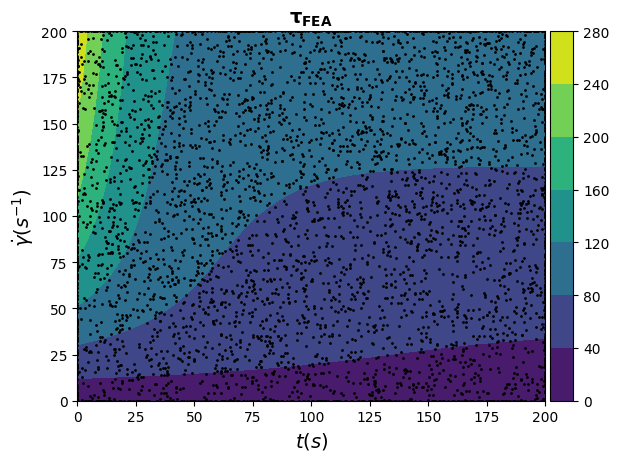

In [9]:
# tau
import pandas as pd
train_lambda=np.loadtxt('train.dat', unpack = True)
train_lambda = pd.DataFrame(train_lambda.T)

ext = griddata(X_star, solution(X_star[:,0],X_star[:,1]), (X, T), method="cubic")
fig, ax = plt.subplots()
h=ax.contourf(X,T, ext,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\tau_{FEA} }$',fontproperties = 'Times New Roman', size = 14)
# plt.yticks(fontproperties = 'Times New Roman', size = 14)
# plt.xticks(fontproperties = 'Times New Roman', size = 14)

plt.scatter(train_lambda[0],train_lambda[1],c='black',s=1)


from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('tau-solution.png',dpi=600,bbox_inches = 'tight')

/tmp/ipykernel_15354/2873265585.py:5: RuntimeWarning: divide by zero encountered in divide
  h=ax.contourf(X,T, ext/T,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
/tmp/ipykernel_15354/2873265585.py:5: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, ext/T,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


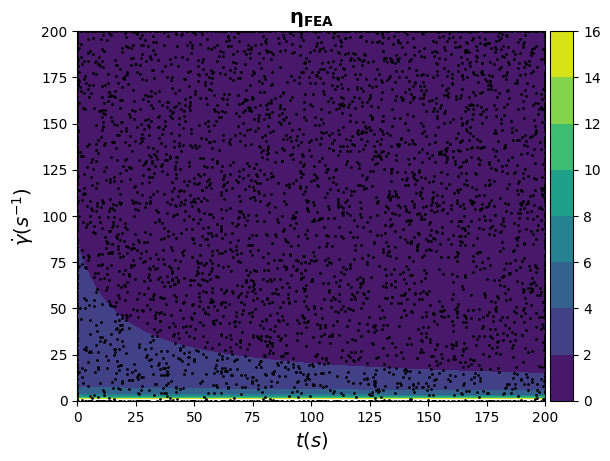

In [11]:
train_lambda=np.loadtxt('train.dat', unpack = True)
train_lambda = pd.DataFrame(train_lambda.T)
ext = griddata(X_star, solution(X_star[:,0],X_star[:,1]), (X, T), method="cubic")
fig, ax = plt.subplots()
h=ax.contourf(X,T, ext/T,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\eta _{FEA}}$',fontproperties = 'Times New Roman', size = 14)
plt.scatter(train_lambda[0],train_lambda[1],c='black',s=1)
# plt.yticks(fontproperties = 'Times New Roman', size = 14)
# plt.xticks(fontproperties = 'Times New Roman', size = 14)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)

plt.savefig('viscosity-solution.png',dpi=600,bbox_inches = 'tight')

# pinn prediction part: tau, lambda, eta, error.

0.010647058486938477


/tmp/ipykernel_15354/866400803.py:17: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, pinn_pre,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


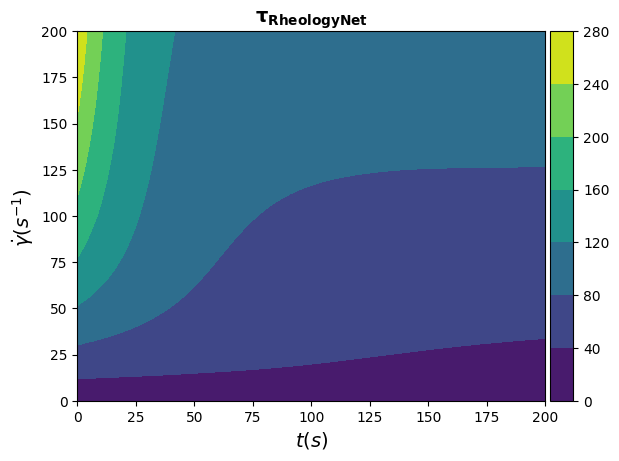

In [17]:
x = np.linspace(0, 200, 200)
t = np.linspace(0, 200, 200)
X, T = np.meshgrid(x, t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

import time
start=time.time()
prediction = model.predict(X_star, operator=None)
end=time.time()
time_pinn = end-start
print(time_pinn)

pinn_pre = griddata(X_star, prediction[:, 0], (X, T), method="cubic")

fig, ax = plt.subplots()
h=ax.contourf(X,T, pinn_pre,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\tau _{RheologyNet} }$',fontproperties = 'Times New Roman', size = 14)
# plt.yticks(fontproperties = 'Times New Roman', size = 14)
# plt.xticks(fontproperties = 'Times New Roman', size = 14)


from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('tau-pinn.png',dpi=600,bbox_inches = 'tight')

# eta

/tmp/ipykernel_15354/647014687.py:13: RuntimeWarning: divide by zero encountered in divide
  h=ax.contourf(X,T, pinn_pre/T,cmap="viridis",origin='lower',aspect='auto',interpolation='nearest')
/tmp/ipykernel_15354/647014687.py:13: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, pinn_pre/T,cmap="viridis",origin='lower',aspect='auto',interpolation='nearest')
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


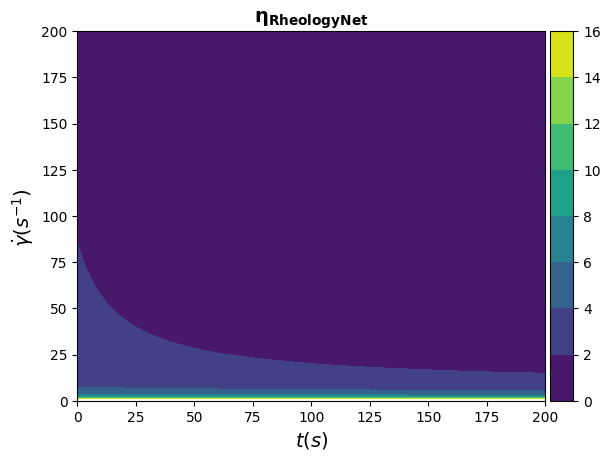

In [18]:
from matplotlib import ticker, cm
x = np.linspace(0, 200, 200)
t = np.linspace(0, 200, 200)
X, T = np.meshgrid(x, t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
prediction = model.predict(X_star, operator=None)

pinn_pre = griddata(X_star, prediction[:, 0], (X, T), method="cubic")

fig, ax = plt.subplots()
# norm = matplotlib.colors.Normalize(vmin=0, vmax=100)
h=ax.contourf(X,T, pinn_pre/T,cmap="viridis",origin='lower',aspect='auto',interpolation='nearest')
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\eta _{RheologyNet} }$',fontproperties = 'Times New Roman', size = 14)


from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('eta-pinn.png',dpi=600,bbox_inches = 'tight')

# nn pre

0.09927201271057129


/tmp/ipykernel_15354/2035749550.py:16: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, pre_nn,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


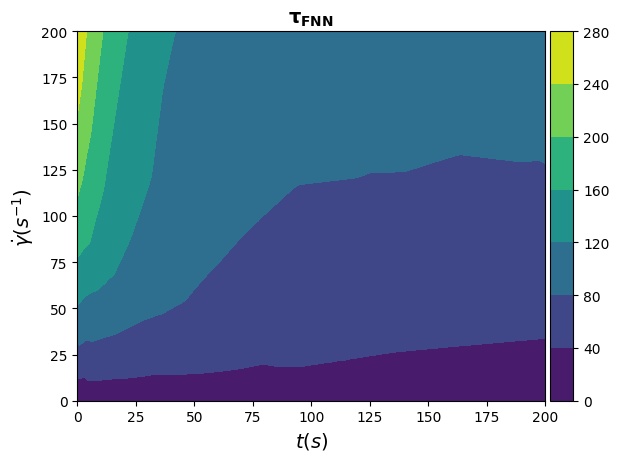

In [19]:
x = np.linspace(0, 200, 200)
t = np.linspace(0, 200, 200)
X, T = np.meshgrid(x, t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

start_fnn=time.time()
prediction = clf.predict(X_star)
end_fnn=time.time()
time_fnn = end_fnn-start_fnn
print(time_fnn)

pre_nn = griddata(X_star, prediction, (X, T), method="cubic")

fig, ax = plt.subplots()
h=ax.contourf(X,T, pre_nn,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\tau _{FNN} }$ ',fontproperties = 'Times New Roman', size = 14)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('tau-FNN.png',dpi=600,bbox_inches = 'tight')

/tmp/ipykernel_15354/3281257233.py:12: RuntimeWarning: divide by zero encountered in divide
  h=ax.contourf(X,T, pre_nn/T,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
/tmp/ipykernel_15354/3281257233.py:12: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, pre_nn/T,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


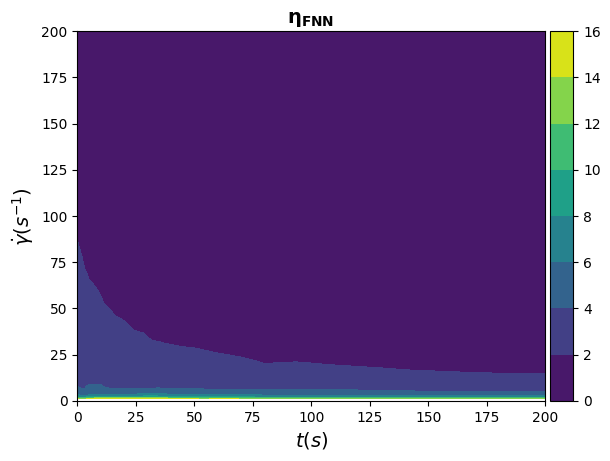

In [20]:
x = np.linspace(0, 200, 200)
t = np.linspace(0, 200, 200)
X, T = np.meshgrid(x, t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

prediction = clf.predict(X_star)

pre_nn = griddata(X_star, prediction, (X, T), method="cubic")

fig, ax = plt.subplots()
h=ax.contourf(X,T, pre_nn/T,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\eta _{FNN} }$ ',fontproperties = 'Times New Roman', size = 14)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('FNN_pre.png',dpi=600,bbox_inches = 'tight')

# nn err

/tmp/ipykernel_15354/3550168273.py:3: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, err_nn,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


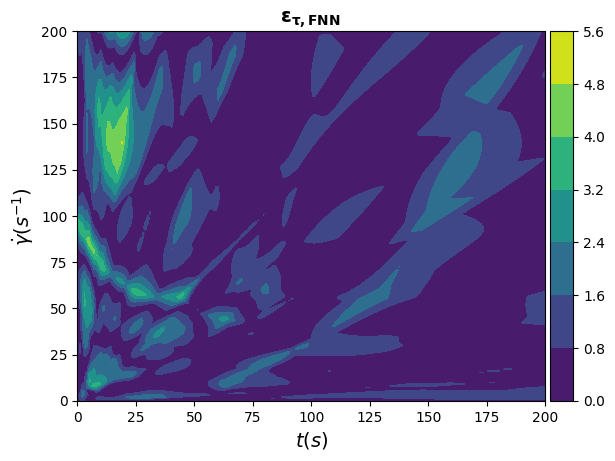

In [21]:
err_nn = abs(pre_nn-ext)
fig, ax = plt.subplots()
h=ax.contourf(X,T, err_nn,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\varepsilon _{\tau ,FNN}   } $ ',fontproperties = 'Times New Roman', size = 14)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('err_tau-FNN.png',dpi=600,bbox_inches = 'tight')

/tmp/ipykernel_15354/319282874.py:1: RuntimeWarning: divide by zero encountered in divide
  err_nn = abs(pre_nn/T-ext/T)
/tmp/ipykernel_15354/319282874.py:1: RuntimeWarning: invalid value encountered in subtract
  err_nn = abs(pre_nn/T-ext/T)
/tmp/ipykernel_15354/319282874.py:3: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, err_nn,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest',locator=ticker.LogLocator())
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


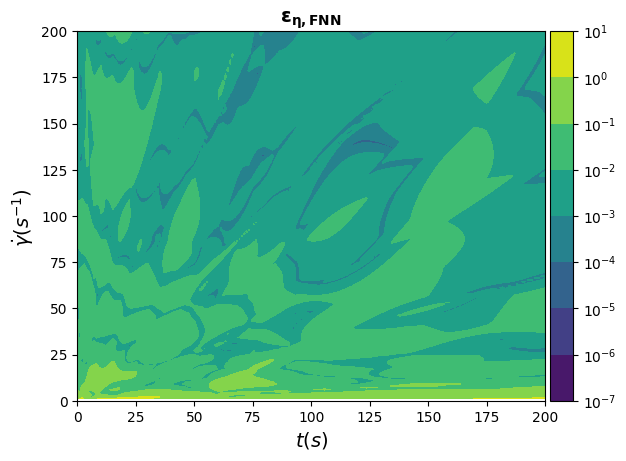

In [22]:
err_nn = abs(pre_nn/T-ext/T)
fig, ax = plt.subplots()
h=ax.contourf(X,T, err_nn,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest',locator=ticker.LogLocator())
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\varepsilon _{\eta ,FNN}   } $ ',fontproperties = 'Times New Roman', size = 14)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('err-FNN-eta.png',dpi=600,bbox_inches = 'tight')

# pinn error

/tmp/ipykernel_15354/3290919119.py:4: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, err_pinn_tau,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


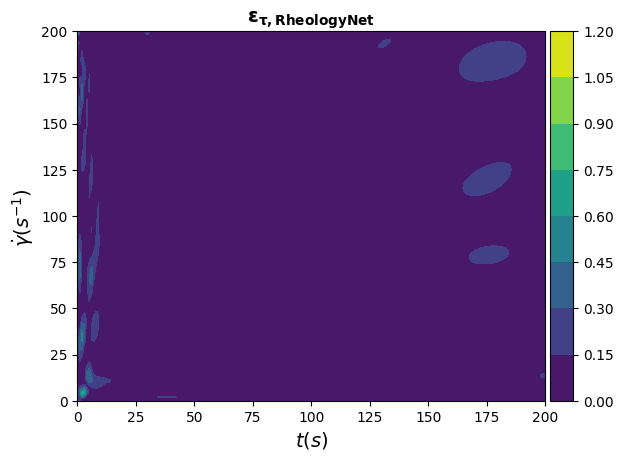

In [23]:
from matplotlib import ticker, cm
err_pinn_tau = abs(pinn_pre-ext)
fig, ax = plt.subplots()
h=ax.contourf(X,T, err_pinn_tau,cmap="viridis",origin='lower', aspect='auto',interpolation='nearest')
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\varepsilon _{\tau ,RheologyNet}  } $ ',fontproperties = 'Times New Roman', size = 14)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('err-rn-tau.png',dpi=600,bbox_inches = 'tight')

/tmp/ipykernel_15354/4192290059.py:1: RuntimeWarning: divide by zero encountered in divide
  err_pinn_eta = abs(pinn_pre/T-ext/T)
/tmp/ipykernel_15354/4192290059.py:1: RuntimeWarning: invalid value encountered in subtract
  err_pinn_eta = abs(pinn_pre/T-ext/T)
/tmp/ipykernel_15354/4192290059.py:3: UserWarning: The following kwargs were not used by contour: 'aspect', 'interpolation'
  h=ax.contourf(X,T, err_pinn_eta,cmap="viridis",origin='lower',aspect='auto',interpolation='nearest',locator=ticker.LogLocator())
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


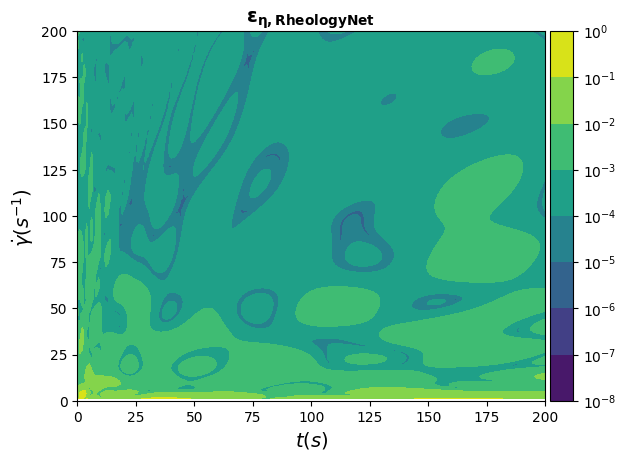

In [24]:
err_pinn_eta = abs(pinn_pre/T-ext/T)
fig, ax = plt.subplots()
h=ax.contourf(X,T, err_pinn_eta,cmap="viridis",origin='lower',aspect='auto',interpolation='nearest',locator=ticker.LogLocator())
plt.xlabel('$t(s)$',fontproperties = 'Times New Roman', size = 14)
plt.ylabel('$\dot{\gamma } ( s^{-1}) $ ',fontproperties = 'Times New Roman', size = 14 )
plt.title(r'$\mathbf{\varepsilon _{\eta ,RheologyNet}  } $ ',fontproperties = 'Times New Roman', size = 14)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)
plt.savefig('err-rn-eta.png',dpi=600,bbox_inches = 'tight')

# PINN MSE

In [29]:
from sklearn.metrics import mean_squared_error
eta_pre= pinn_pre/T
eta_pre[eta_pre>1e308]=0

eta_ext=ext/T
eta_ext[eta_ext>1e308]=0
eta_nn = pre_nn/T

eta_nn[eta_nn>1e308]=0

print('tau-mse-pinn',mean_squared_error(pinn_pre,ext))
print('eta-mse-pinn',mean_squared_error(eta_pre,eta_ext))
print('tau-mse-fnn',mean_squared_error(pre_nn,ext))
print('eta-mse-fnn',mean_squared_error(eta_nn,eta_ext))

print('pinn_time',time_pinn)
print('fnn_time',time_fnn)

tau-mse-pinn 0.005185787039689276
eta-mse-pinn 5.618273328708645e-05
tau-mse-fnn 1.0561918090749998
eta-mse-fnn 0.0068271780782483684
pinn_time 0.010647058486938477
fnn_time 0.09927201271057129


/tmp/ipykernel_15354/435361120.py:2: RuntimeWarning: divide by zero encountered in divide
  eta_pre= pinn_pre/T
/tmp/ipykernel_15354/435361120.py:5: RuntimeWarning: divide by zero encountered in divide
  eta_ext=ext/T
/tmp/ipykernel_15354/435361120.py:7: RuntimeWarning: divide by zero encountered in divide
  eta_nn = pre_nn/T
